In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import netCDF4
import numpy as np
import xarray as xr
#import pandas as pd 
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#from cartopy.util import add_cyclic_point
from windspharm.xarray import VectorWind
mpl.rcParams['mathtext.default'] = 'regular'
#import numpy as np
import cartopy.feature as feature

In [2]:
ds1=xr.open_dataset('Regression_SST_spatial_pattern_IOD_ERSSTv5-23models.nc')
ds2=xr.open_dataset('Regression_SST_spatial_pattern_IOD_MMM.nc')

IOD1=ds1['SLOPE_M'][0,:,:]
IOD2=ds1['SLOPE_M'][1,:,:]
IOD3=ds1['SLOPE_M'][2,:,:]
IOD4=ds1['SLOPE_M'][3,:,:]
IOD5=ds1['SLOPE_M'][4,:,:]
IOD6=ds1['SLOPE_M'][5,:,:]
IOD7=ds1['SLOPE_M'][6,:,:]
IOD8=ds1['SLOPE_M'][7,:,:]
IOD9=ds1['SLOPE_M'][8,:,:]
IOD10=ds1['SLOPE_M'][9,:,:]

print(ds1.coords)
#print(ds9)
#weight=ds9['clat']
#wslope1=slope1*weight
#weight.shape
print(ds1.coords)
LON = ds1.LON.data
LAT = ds1.LAT.data
LON=np.linspace(40,110,71)
LAT=np.linspace(-20,25,45)
LON,LAT=np.meshgrid(LON,LAT)

#LON1 = ds9.LON.data
#LAT1 = ds9.LAT.data
#LON1=np.linspace(40,110,36)
#LAT1=np.linspace(-20,25,23)
#LON1,LAT1=np.meshgrid(LON1,LAT1)


Coordinates:
  * TIME     (TIME) float64 192B 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON      (LON) float64 568B 40.0 41.0 42.0 43.0 ... 107.0 108.0 109.0 110.0
  * LAT      (LAT) float64 360B -19.45 -18.45 -17.45 ... 22.44 23.43 24.43
Coordinates:
  * TIME     (TIME) float64 192B 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON      (LON) float64 568B 40.0 41.0 42.0 43.0 ... 107.0 108.0 109.0 110.0
  * LAT      (LAT) float64 360B -19.45 -18.45 -17.45 ... 22.44 23.43 24.43


In [3]:
IOD11=ds1['SLOPE_M'][10,:,:]
IOD12=ds1['SLOPE_M'][11,:,:]
IOD13=ds1['SLOPE_M'][12,:,:]
IOD14=ds1['SLOPE_M'][13,:,:]
IOD15=ds1['SLOPE_M'][14,:,:]
IOD16=ds1['SLOPE_M'][15,:,:]
IOD17=ds1['SLOPE_M'][16,:,:]
IOD18=ds1['SLOPE_M'][17,:,:]
IOD19=ds1['SLOPE_M'][18,:,:]
IOD20=ds1['SLOPE_M'][19,:,:]
IOD21=ds1['SLOPE_M'][20,:,:]
IOD22=ds1['SLOPE_M'][21,:,:]
IOD23=ds1['SLOPE_M'][22,:,:]
IOD24=ds1['SLOPE_M'][23,:,:]
IOD25=ds2['MMM'][:,:]


In [4]:
datasets = [
    (IOD1, "(a) ERSSTv5 (EOF2-12.7%)"),
    (IOD2, "(b) CanESM5 (EOF2-9.3%)"),
    (IOD3, "(c) HadGEM3-GC31-LL (EOF2-14.0%)"),
    (IOD4, "(d) EC-Earth3-CC (EOF2-19.9%)"),
    (IOD5, "(e) CMCC-CM2-SR5 (EOF1-28.8%)"),
    (IOD6, "(f) CNRM-CM6-1 (EOF2-18.4%)"),
    (IOD7, "(g) GISS-E2-1-G (EOF2-13.5%)"),
    (IOD8, "(h) CMCC-ESM2 (EOF2-15.7%)"),
    (IOD9, "(i) EC-Earth3 (EOF2-18.2%)"),
    (IOD10, "(j) E3SM1-0 (EOF2-20.2%)"),
    (IOD11, "(k) MIROC6 (EOF2-14.1%)"),
    (IOD12, "(l) MRI-ESM2-0 (EOF2-20.1%)"),
    (IOD13, "(m) HadGEM3-GC31-MM (EOF2-14.7%)"),
    (IOD14, "(n) BCC-CSM2-MR (EOF2-16.9%)"),
    (IOD15, "(o) IPSL-CM6A-LR (EOF2-11.6%)"),
    (IOD16, "(p) MPI-ESM1-2-HR (EOF2-10.3%)"),
    (IOD17, "(q) ACCESS-ESM1-5 (EOF1-20.2%)"),
    (IOD18, "(r) ACCESS-CM2 (EOF2-11.1%)"),
    (IOD19, "(s) CESM2 (EOF1-30.3%)"),
    (IOD20, "(t) GFDL-CM4 (EOF1-12.7%)"),
    (IOD21, "(u) CIESM (EOF1-31.2%)"),
    (IOD22, "(v) FGOALS-g3 (EOF1-24.9%)"),
    (IOD23, "(w) SAM0-UNICON (EOF1-27.2%)"),
    (IOD24, "(x) CNRM-ESM2-1 (EOF2-18.7%)"),
    (IOD25, "(y) MMM")
]

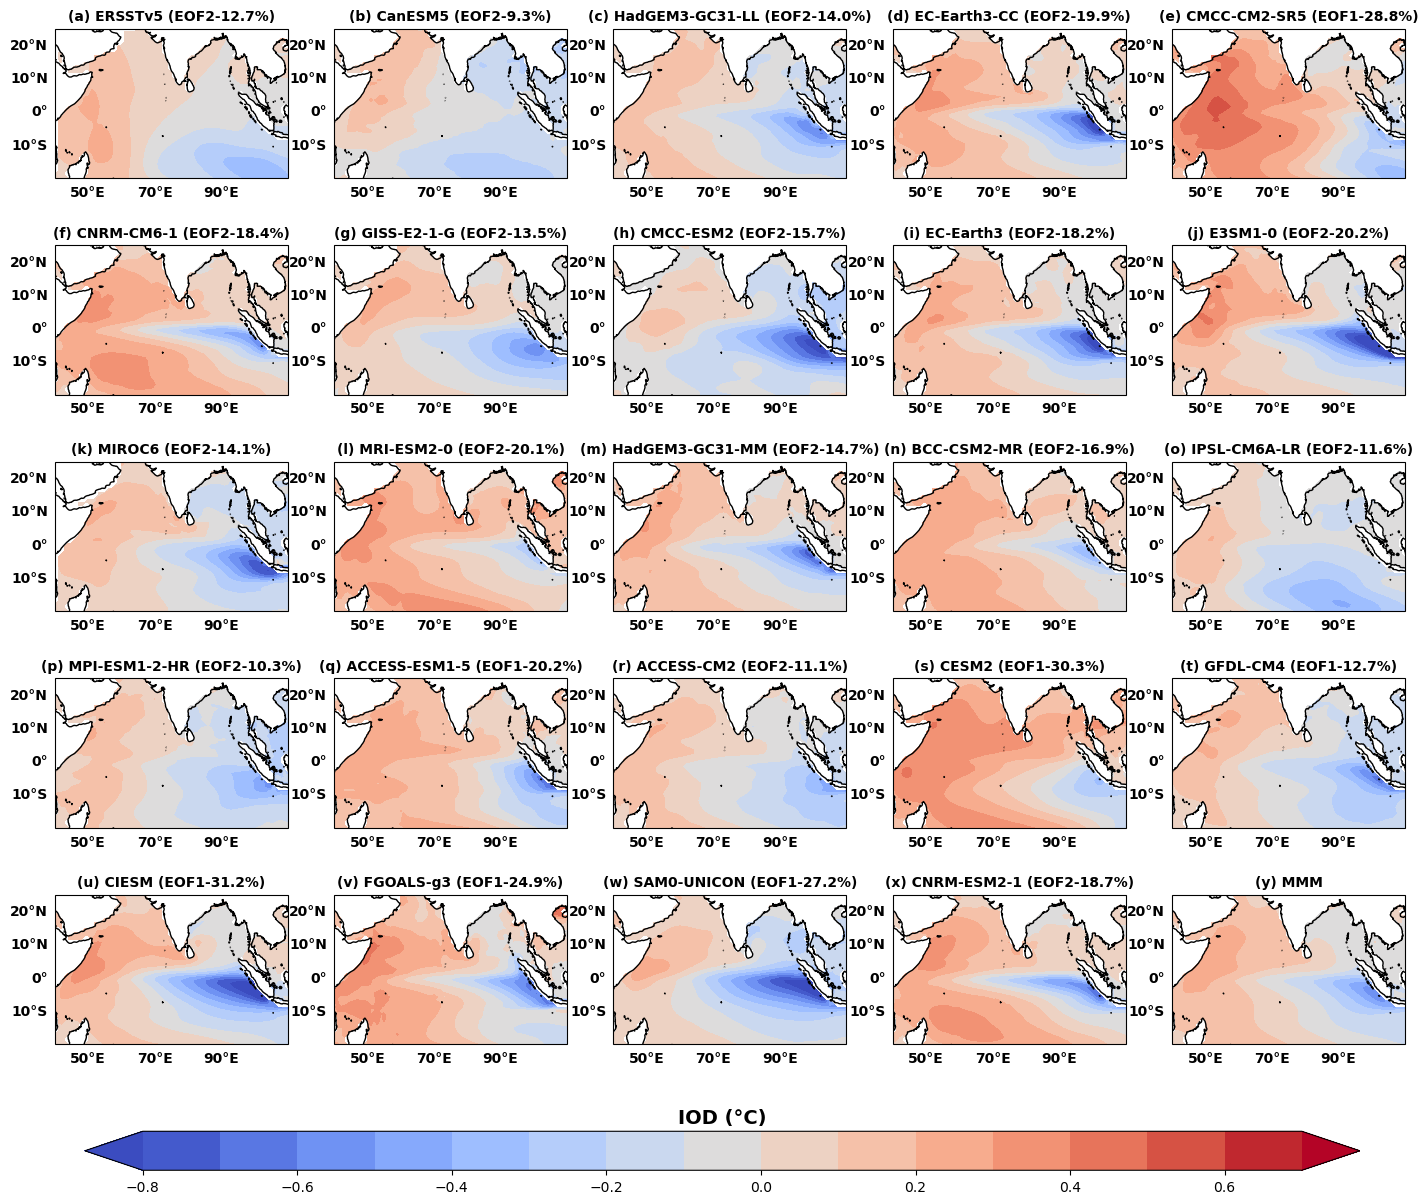

In [6]:
# Subplot configuration
nrows, ncols = 5, 5
start_index = 1  # Starting index for subplots
projection = ccrs.PlateCarree(central_longitude=80)
clevs = np.arange(-0.8, 0.8, 0.1)

# Create figure
fig = plt.figure(figsize=(15, 19.5))
# Store the last `contourf` plot for the colorbar
last_fill_sf = None

for i, (data, title) in enumerate(datasets, start=start_index):
    ax = plt.subplot(nrows, ncols, i, projection=projection)
    fill_sf = ax.contourf(LON, LAT, data, levels=clevs, cmap=plt.cm.coolwarm, transform=ccrs.PlateCarree(), extend='both')
    last_fill_sf = fill_sf  # Update the last contourf object
    ax.set_aspect('equal')
    ax.coastlines()
    ax.set_title(title, fontsize=10, loc='center', color='black', fontweight='bold')
    #ax.annotate(annotation, xy=(0.5, -0.15), xycoords='axes fraction', ha='center', va='top', fontsize=10, color='red', fontweight='bold')
    # Gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
# --- Longitude labels ---
    gl.top_labels = False       # no longitude labels on top
    gl.bottom_labels = True     # show longitude labels only on the bottom
# --- Latitude labels ---
    gl.left_labels = True       # keep latitude labels on the left
    gl.right_labels = False     # no latitude labels on the right
# --- Gridline drawing ---
    gl.xlines = False           # don't draw the longitude gridlines themselves
    gl.ylines = False           # don't draw the latitude gridlines themselves
# --- Formatters ---
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# Adjust layout (moved outside the `if` block)
plt.subplots_adjust(bottom=0.4, left=0.08, right=0.98, top=0.95, hspace=0.05)

# Add colorbar
if last_fill_sf is not None:  # Check if a valid contourf object exists
    cax = plt.axes([0.1, 0.35, 0.85, 0.02])  # Adjust these values for proper placement
    clb = plt.colorbar(last_fill_sf, cax=cax, orientation='horizontal', fraction=0.1, pad=0.05)
    clb.ax.set_title('IOD (°C)', loc='center', color='black', fontsize=14, fontweight='bold')

# Save and show plot
plt.savefig('panel25_regression_IOD_models_observations_mmm.png', dpi=600)
plt.show()